In [6]:
import torch
from neuromancer.loggers import BasicLogger
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import integrators

#from SparseDPC.src.library import FunctionLibrary
from SparseDPC.src.sindy.fx_library import fx_library
from SparseDPC.src.data.getdata import get_data
from SparseDPC.src.trainer.trainer import SparseTrainer
#from SparseDPC.src.trainer.trainer import SparseDynamicsTrainer, SparsePolicyTrainer
torch.manual_seed(86)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [7]:
# ground truth system model
gt_model = psl.nonautonomous.TwoTank()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = 0.
umax = 1.
xmin = 0.
xmax = 1



In [8]:
fx_models = [fx_library(i, nx=nx, nu=nu, device=device) for i in range(nx)]
for fx in fx_models:
    print(fx)

dx0/dt = 0.867*x0 + 0.226*x1 + 0.016*x0^2 + 0.352*x1^2 + 0.075*x0*x1 + 0.878*u_0 + 0.176*u_1 + 0.391*u_0*u_1 + 0.221*x0*u_0 + 0.574*x1*u_0 + 0.005*x0*u_1 + 0.131*x1*u_1 + 0.840*sqrt(x0) + 0.904*sqrt(x1) 

dx1/dt = 0.942*x1 + 0.940*x0 + 0.142*x1^2 + 0.163*x0^2 + 0.609*x1*x0 + 0.634*u_0 + 0.090*u_1 + 0.842*u_0*u_1 + 0.659*x1*u_0 + 0.506*x0*u_0 + 0.756*x1*u_1 + 0.357*x0*u_1 + 0.745*sqrt(x1) + 0.378*sqrt(x0) 



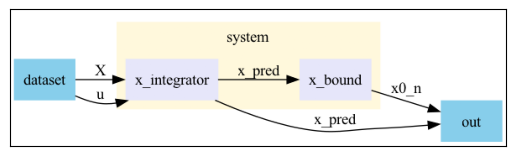

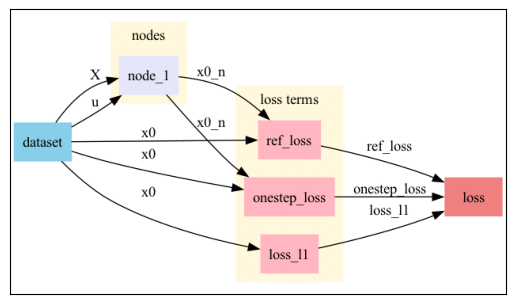

None
epoch: 0	train_loss: 1.80573	dev_loss: 1.54046	eltime:  0.81286
epoch: 100	train_loss: 0.01962	dev_loss: 0.02371	eltime:  3.69084
epoch: 200	train_loss: 0.00652	dev_loss: 0.01032	eltime:  6.55639
epoch: 300	train_loss: 0.00142	dev_loss: 0.00254	eltime:  9.22263
epoch: 400	train_loss: 0.00035	dev_loss: 0.00040	eltime:  11.83692
epoch: 500	train_loss: 0.00010	dev_loss: 0.00014	eltime:  14.42175
epoch: 600	train_loss: 0.00003	dev_loss: 0.00007	eltime:  17.00512
epoch: 700	train_loss: 0.00003	dev_loss: 0.00006	eltime:  19.58402

---------- Model 0 BEFORE pruning ----------
dx0/dt = 0.162*x0 + -0.282*x1 + -0.054*x0^2 + 0.192*x1^2 + -0.040*x0*x1 + 0.021*u_0 + -0.021*u_1 + 0.046*u_0*u_1 + -0.178*x0*u_0 + 0.202*x1*u_0 + -0.166*x0*u_1 + 0.102*x1*u_1 + -0.068*sqrt(x0) + 0.106*sqrt(x1) 

   Threshold=0.002  Active=14  (prev=14)
   Pruned terms: []

⇒ No change in active sets; coefficients kept.

---------- Model 0 AFTER pruning  ----------
dx0/dt = 0.162*x0 + -0.282*x1 + -0.054*x0^2 + 0.192*

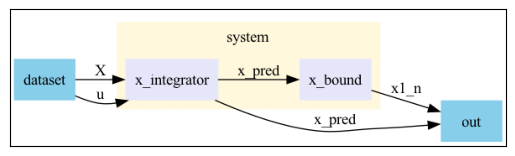

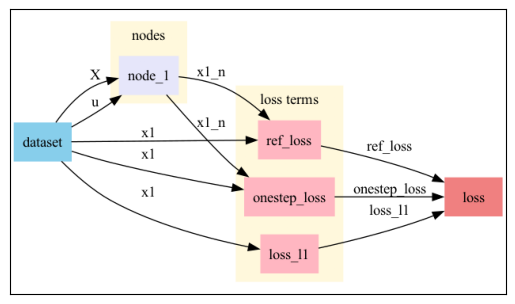

None
epoch: 0	train_loss: 1.17739	dev_loss: 1.26427	eltime:  0.71383
epoch: 100	train_loss: 0.00178	dev_loss: 0.00359	eltime:  3.31129
epoch: 200	train_loss: 0.00261	dev_loss: 0.00159	eltime:  5.89349
epoch: 300	train_loss: 0.00078	dev_loss: 0.00088	eltime:  8.47182
epoch: 400	train_loss: 0.00055	dev_loss: 0.00049	eltime:  11.05881
epoch: 500	train_loss: 0.00028	dev_loss: 0.00025	eltime:  13.63610
epoch: 600	train_loss: 0.00013	dev_loss: 0.00017	eltime:  16.27123
epoch: 700	train_loss: 0.00006	dev_loss: 0.00011	eltime:  18.88499

---------- Model 0 BEFORE pruning ----------
dx1/dt = 0.068*x1 + 0.280*x0 + -0.228*x1^2 + -0.222*x0^2 + 0.303*x1*x0 + 0.062*u_0 + -0.010*u_1 + 0.182*u_0*u_1 + -0.103*x1*u_0 + -0.191*x0*u_0 + 0.043*x1*u_1 + -0.183*x0*u_1 + -0.005*sqrt(x1) + -0.136*sqrt(x0) 

   Threshold=0.002  Active=14  (prev=14)
   Pruned terms: []

⇒ No change in active sets; coefficients kept.

---------- Model 0 AFTER pruning  ----------
dx1/dt = 0.068*x1 + 0.280*x0 + -0.228*x1^2 + -0.222

In [9]:
for i in range(nx):

    nsim = 2000   # number of simulation steps in the dataset
    nsteps = 2  # number of prediction horizon steps in the loss function
    bs = 100     # minibatching batch size
    train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

    integrator_x = integrators.Euler(fx_models[i], h=ts)

    integrator_node_x = Node(integrator_x, ['X', 'u'], ['x_pred'], name="x_integrator")
    x1_bound = Node(lambda x: torch.clamp(x, xmin, xmax)[:,i:i+1], ['x_pred'], [f'x{i}_n'], name="x_bound")
    dynamics_model_x = System([integrator_node_x, x1_bound])
    dynamics_model_x.show()

    x = variable(f"x{i}")
    x_hat = variable(f'x{i}_n')[:, :-1, :]

    # Loss
    onestep_loss_x = 1.0 * ((x_hat[:, 1, :] == x[:, 1, :])^ 2)
    onestep_loss_x.name = "onestep_loss"

    reference_loss_x = 5. *((x_hat == x) ^ 2)
    reference_loss_x.name = "ref_loss"

    # Sparsity constraint
    l1_x = variable([x], lambda x: torch.norm(list(fx_models[i].parameters())[0], p=1))
    loss_l1_x = 0.000001 * (l1_x == 0)
    loss_l1_x.name = "loss_l1"

    objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
    loss_x = PenaltyLoss(objectives_x, [])
    problem_x = Problem([dynamics_model_x], loss_x)
    problem_x.show()

    lr = 1e-3
    optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

    logger = BasicLogger(args=None, savedir='test', verbosity=100,
                    stdout=['dev_loss', 'train_loss'])
    epochs=7500


    # trainer_x = SparseDynamicsTrainer(
    # problem_x,
    # fx_models[i],
    # lr,
    # None,
    # None,
    # optimizer=optimizer_x,
    # epochs=epochs,
    # train_metric='train_loss',
    # eval_metric='dev_loss',
    # logger=logger,
    # device=device,
    # threshold=0.002,
    # prune_every=750,
    # warmup=300,
    # patience=50,
    # threshold_mult=1.07
    # )

    trainer_x = SparseTrainer(
        problem      = problem_x,
        fx_models  = [fx_models[i]],      # list of SINDy models
        lr           = 1e-3,
        train_data=None,
        test_data=None,
        optimizers=[optimizer_x],
        epochs=epochs,
        train_metric='train_loss',
        eval_metric='dev_loss',
        logger=logger,
        device=device,
        threshold=0.002,
        prune_every=750,
        warmup=300,
        patience=50,
        threshold_mult=1.07,
        )
    for _ in range(1):
        # print(f'************   training with {nsteps} steps   ************   ')

        # Regenerate data for the new `nsteps`
        train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)
        trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
        trainer_x.problem = problem_x  # Keep the problem consistent

        # Train control policy
        best_model = trainer_x.train()


        trainer_x.model.load_state_dict(best_model)

        # Update step size
        nsteps *= 2
        # trainer.model.loss.objectives[2].weight *= 1.1
        dynamics_model_x.nsteps = nsteps



In [11]:
for fx in fx_models:
    print(fx)

dx0/dt = -0.039*sqrt(x0) + 0.078*u_0 + -0.078*u_0*u_1 

dx1/dt = -0.040*sqrt(x1) + 0.040*sqrt(x0) + 0.080*u_0*u_1 

